In [207]:
import blackjax

from typing import Callable, NamedTuple, Optional

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from blackjax.smc.resampling import systematic
from blackjax.smc.ess import ess

In [232]:
class ParticleFilterState(NamedTuple):
    particles: jnp.ndarray
    weights: jnp.ndarray
    ancestors: jnp.ndarray
    time: int

class ParticleFilterInfo(NamedTuple):
    pass

Incremental importance weight.

Assuming we use $q(x_n|x_{n-1})$ to approximate $p(x_n|x_{n-1})$, we have the following incremental importance weight:

$$ \alpha(x_n) = \frac{p(x_{1:n}|y_{1:n})}{p(x_{1:n-1}|y_{1:n-1}) p(x_n|x_{n-1})} = \frac{p(x_n|x_{n-1}) p(y_n|x_{n})}{p(x_n|x_{n-1})p(y_n|y_{n-1})} $$ 

In [319]:
def init(particles):
    weights = jnp.ones((particles.shape[0],)) / particles.shape[0]
    idx = jnp.arange(particles.shape[0])
    return ParticleFilterState(particles, weights,idx, 0)

def build_kernel(
    log_likelihood_fn: Callable,
    transition_fn: Callable,
    resample_criterion: Callable,
    resample_fn: Callable,
    ):
    
    def kernel(
        rng_key,
        state: ParticleFilterState,
        observed = None,
    ):
        particles = state.particles
        weights = state.weights
        
        # Predict
        new_particles = transition_fn(rng_key, particles, state.time)
        
        # Update
        if observed is not None:
            log_weights = log_likelihood_fn(new_particles, observed) + jnp.log(weights)
            log_weights = log_weights - jnp.max(log_weights)
            new_weights = jax.nn.softmax(log_weights)
            
            # Resample
            if resample_criterion(state):
                idx = resample_fn(rng_key, new_weights, particles.shape[0])
                new_particles = particles[idx]
                new_weights = jnp.ones_like(new_weights) / particles.shape[0]
            else:
                idx = state.ancestors
        else:
            new_weights = weights
            idx = state.ancestors
            
 

        return ParticleFilterState(new_particles, new_weights, idx,state.time + 1), ParticleFilterInfo()
    
    return kernel

In [320]:
def log_likelihood_fn(x,y):
    return jax.scipy.stats.norm.logpdf(y, x, 1.5)

def transition_fn(key,x,index):
    return jax.random.normal(key, shape=x.shape) + x

def resample_criterium(state):
    num_particles = state.particles.shape[0]
    effective_samples = ess(jnp.log(state.weights))
    print(effective_samples)
    return effective_samples < 0.5*num_particles

In [321]:
key = jax.random.PRNGKey(0)
state = init(jax.random.normal(key, (100,)))
kernel = build_kernel(log_likelihood_fn, transition_fn, resample_criterium,systematic)

In [322]:
sequence = [state]
y_os = jax.random.normal(key, shape=(50,))
j = 0
obs_i = []
for i in range(30):
    key, key_sample = jax.random.split(key)
    if (i) % 3 != 1:
        new_state, _ = kernel(key_sample, sequence[-1])
    else:
        new_state, _ = kernel(key_sample, sequence[-1], y_os[j])
        j += 1
        obs_i.append(i)
    sequence.append(new_state)

100.0
81.44047
59.86229
45.005585
100.0
74.87058
49.70263
100.0
71.849205
52.793182


In [337]:
traces = jnp.array([s.particles for s in sequence])
ancestors = jnp.array([s.ancestors for s in sequence])
weights = jnp.array([s.weights for s in sequence])

In [332]:
ancestors[12]

Array([ 0,  4,  5,  5,  5,  6,  6,  6,  6,  7,  8,  8, 12, 13, 13, 13, 17,
       17, 17, 18, 18, 18, 19, 19, 19, 22, 23, 25, 28, 28, 28, 31, 31, 32,
       32, 32, 32, 33, 33, 35, 42, 45, 45, 46, 46, 46, 47, 47, 47, 47, 47,
       49, 49, 50, 50, 50, 50, 51, 52, 55, 56, 60, 60, 60, 62, 71, 74, 75,
       78, 78, 78, 78, 79, 79, 79, 79, 79, 79, 84, 84, 84, 85, 85, 85, 85,
       86, 88, 88, 88, 89, 89, 91, 91, 91, 91, 91, 94, 98, 98, 98],      dtype=int32)

In [334]:
# reconstruct the path of the particles
path = [traces[-1,:]]
current_ancestors = ancestors[-1]
for i in range(len(ancestors)-1, 0, -1):
    if all(current_ancestors != ancestors[i-1]):
        current_ancestors = ancestors[i-1]
        path.append(traces[i, current_ancestors])
    else:
        path.append(traces[i,:])
path = jnp.array(path)

/tmp/ipykernel_2075/2368894176.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = plt.cm.get_cmap('viridis', 256)


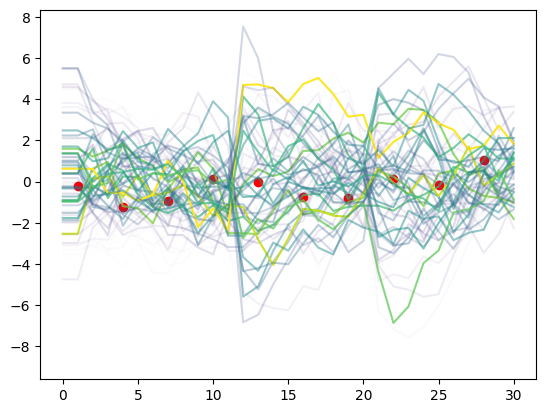

In [336]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Get the 'viridis' colormap
viridis = plt.cm.get_cmap('viridis', 256)

# Create a new colormap where the alpha value varies linearly
newcolors = viridis(np.linspace(0, 1, 256))
alphas = np.linspace(0, 1, 256)
newcolors[:, -1] = alphas
cmap = mcolors.ListedColormap(newcolors)

# Now you can use `newcmp` as your colormap
weights = weights / weights.max()

for i in range(traces.shape[1]):
    # Get the RGBA color from the colormap
    rgba = cmap(weights[i])
    
    # Use the alpha channel as the transparency of the line
    plt.plot(path[:, i], c=rgba)

plt.scatter(obs_i, y_os[:len(obs_i)], color="red")

plt.show()

In [482]:
import numpy as np

# Parameters
A = 1.001  # State transition coefficient
H = 1.0   # Observation matrix
Q = 1.   # Process noise variance
R = 0.   # Measurement noise variance
num_particles = 1000
num_steps = 100

# Initialization
particles = np.random.normal(0, np.sqrt(Q), num_particles)
weights = np.full(num_particles, 1.0 / num_particles)

# Simulate some data
true_states = np.zeros(num_steps)
observations = np.zeros(num_steps)
true_states[0] = np.random.normal(0, np.sqrt(Q))
observations[0] = H * true_states[0] + np.random.normal(0, np.sqrt(R))
for t in range(1, num_steps):
    true_states[t] = A * true_states[t - 1] + np.random.normal(0, np.sqrt(Q))
    observations[t] = H * true_states[t] + np.random.normal(0, np.sqrt(R))

filtered_particles = np.zeros((num_steps, num_particles))
# Forward Filtering
for t in range(1, num_steps):
    particles = A * particles + np.random.normal(0, np.sqrt(Q), num_particles)
    weights *= [np.exp(-0.5 * ((observations[t] - H * p) ** 2) / R) for p in particles]
    weights /= np.sum(weights)
    # Resampling
    indices = np.random.choice(range(num_particles), num_particles, p=weights)
    particles = particles[indices]
    weights.fill(1.0 / num_particles)
    filtered_particles[t] = particles

# Backward Smoothing
smoothed_particles = np.zeros((num_steps, num_particles))
smoothed_particles[-1] = particles
for t in range(num_steps - 2, -1, -1):
    for i in range(num_particles):
        ancestor = np.random.choice(range(num_particles), p=weights)
        smoothed_particles[t, i] = A * smoothed_particles[t + 1, ancestor] + np.random.normal(0, np.sqrt(Q))

# Estimate the smoothed states
smoothed_states = np.mean(smoothed_particles, axis=1)
smoothed_var = np.var(smoothed_particles, axis=1)

filtered_states = np.mean(filtered_particles, axis=1)

In [490]:
import numpy as np

# Parameters
A = 1.  # State transition coefficient
H = 1.0   # Observation matrix
Q = 0.5    # Process noise variance
R = 0.01   # Measurement noise variance
num_particles = 1000
num_steps = 1000
observation_interval = 300  # Observations are made every 10 steps

# Initialization
particles = np.random.normal(0, np.sqrt(Q), num_particles)
weights = np.full(num_particles, 1.0 / num_particles)

# Simulate some data
true_states = np.zeros(num_steps)
observations = np.full(num_steps, np.nan)  # Initialize observations as NaN
true_states[0] = np.random.normal(0, np.sqrt(Q))
observations[0] = H * true_states[0] + np.random.normal(0, np.sqrt(R))
for t in range(1, num_steps):
    true_states[t] = A * true_states[t - 1] + np.random.normal(0, np.sqrt(Q))
    if t % observation_interval == 0:
        observations[t] = H * true_states[t] + np.random.normal(0, np.sqrt(R))

filtered_particles = np.zeros((num_steps, num_particles))
ancestor_indices = np.zeros((num_steps, num_particles), dtype=int)
weights_record = np.full((num_steps, num_particles), 1.0 / num_particles)

# Forward Filtering
for t in range(1, num_steps):
    particles = A * particles + np.random.normal(0, np.sqrt(Q), num_particles)
    if not np.isnan(observations[t]):
        weights *= np.exp(-0.5 * ((observations[t] - H * particles) ** 2) / R)
        weights /= np.sum(weights)
        weights_record[t] = weights  # Record the weights at observation times
        indices = np.random.choice(range(num_particles), num_particles, p=weights)
        particles = particles[indices]
        ancestor_indices[t] = indices
        weights.fill(1.0 / num_particles)
    filtered_particles[t] = particles

# Backward Smoothing
# Backward Smoothing
smoothed_particles = np.zeros((num_steps, num_particles))
smoothed_particles[-1, :] = filtered_particles[-1, :]

# Start from the end and move backwards
for t in range(num_steps - 2, -1, -1):
    # Compute weights for each particle at time t
    weights_backward = np.zeros(num_particles)
    for i in range(num_particles):
        # Here we calculate the transition probability density of each particle at t given the
        # smoothed particle at t+1.
        weights_backward[i] = weights_record[t, i] * np.exp(
            -0.5 * ((smoothed_particles[t + 1, i] - A * filtered_particles[t, i]) ** 2) / Q)

    # Normalize the backward weights
    weights_backward /= sum(weights_backward)

    # Resample based on the backward weights
    indices = np.random.choice(num_particles, size=num_particles, p=weights_backward)
    smoothed_particles[t] = filtered_particles[t, indices]

smoothed_states = np.mean(smoothed_particles, axis=1)
smoothed_var = np.var(smoothed_particles, axis=1)

filtered_states = np.mean(filtered_particles, axis=1)
filtered_var = np.var(filtered_particles, axis=1)



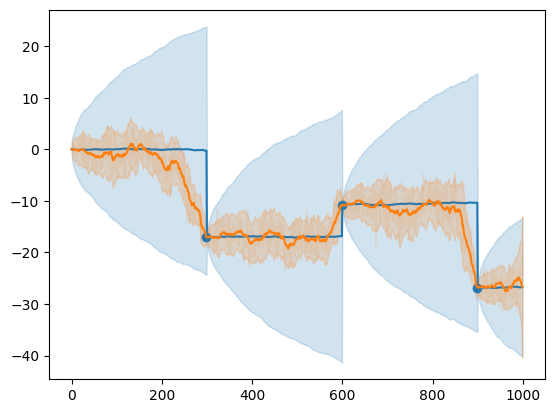

In [491]:
import matplotlib.pyplot as plt

plt.plot(observations[1:], label="True States", marker="o")
plt.plot(filtered_states, label="Filtered States", color="C0")
plt.fill_between(range(num_steps), filtered_states - 2 * np.sqrt(filtered_var), filtered_states + 2 * np.sqrt(filtered_var), alpha=0.2, color="C0")
plt.plot(smoothed_states, label="Smoothed States", color="C1")
plt.fill_between(range(num_steps), smoothed_states - 2 * np.sqrt(smoothed_var), smoothed_states + 2 * np.sqrt(smoothed_var), alpha=0.2, color="C1")
plt.plot(smoothed_particles[:,0], color="C1", alpha=0.1, label="Smoothed Particles")